<a href="https://colab.research.google.com/github/Awimya-Rn/PCVK26_13_Ilham/blob/main/Week5_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Mokhammad Ilham Putra Wijaya'
NIM = '244107020139'
N = int(NIM[-3:])
PARAM = {
 'bins' : 2 ** ((N % 4) + 3),
 'clip' : round(1.0 + (N % 5) * 0.5, 1),
 'tile' : (N % 4) + 2,
 'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
 print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Mokhammad Ilham Putra Wijaya
NIM : 244107020139 | N = 139
bins   : 64
clip   : 3.0
tile   : 5
L      : 4
WAKTU : 2026-09-26 23:40:58 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 8457e7401fdfa342


# E-1 PERCOBAAN HISTOGRAM

## import folder yang ada di Drive Anda

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import beberapa library berikut yang akan digunakan selama uji coba praktikum minggu ke-5 berikut

In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

## Membuat histogram citra

<BarContainer object of 256 artists>

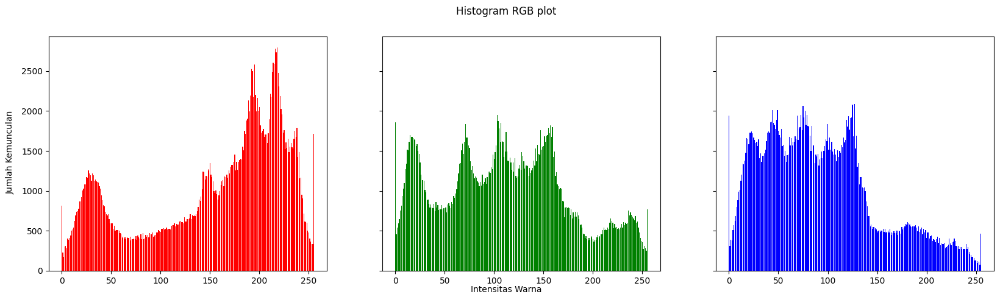

In [ ]:
img=cv.imread('/content/drive/MyDrive/PCVK/Images/244107020139/lena.jpg')
img=cv.cvtColor(img,cv.COLOR_BGR2RGB)

height, width, depth=np.shape(img)
names=np.arange(256)

red=[0]*256
green=[0]*256
blue=[0]*256

for y in range(0,height):
  for x in range(0,width):
    red[img[y][x][0]]+=1
    green[img[y][x][1]]+=1
    blue[img[y][x][2]]+=1

names=np.arange(256)
fig,axs=plt.subplots(1,3,figsize=[20,5],sharex=True,sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09,0.5,'Jumlah Kemunculan',va='center',rotation='vertical')
fig.text(0.5,0.04,'Intensitas Warna',ha='center')
axs[0].bar(names,red,color='red')
axs[1].bar(names,green,color='green')
axs[2].bar(names,blue,color='blue')

## ulangi dengan citra KTM1b.jpg

<BarContainer object of 256 artists>

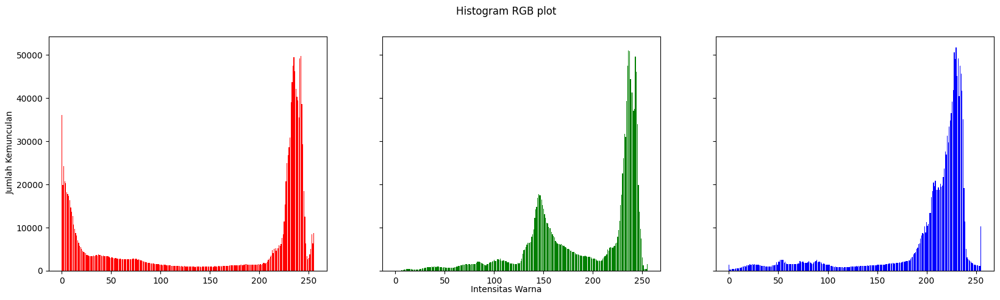

In [ ]:
img_ktm1b=cv.imread('/content/drive/MyDrive/PCVK/Images/244107020139/KTM1b.jpeg')
img_ktm1b=cv.cvtColor(img_ktm1b,cv.COLOR_BGR2RGB)

height_ktm1b, width_ktm1b, depth_ktm1b=np.shape(img_ktm1b)
names=np.arange(256)

red_ktm1b=[0]*256
green_ktm1b=[0]*256
blue_ktm1b=[0]*256

for y in range(0,height_ktm1b):
  for x in range(0,width_ktm1b):
    red_ktm1b[img_ktm1b[y][x][0]]+=1
    green_ktm1b[img_ktm1b[y][x][1]]+=1
    blue_ktm1b[img_ktm1b[y][x][2]]+=1

names=np.arange(256)
fig,axs=plt.subplots(1,3,figsize=[20,5],sharex=True,sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09,0.5,'Jumlah Kemunculan',va='center',rotation='vertical')
fig.text(0.5,0.04,'Intensitas Warna',ha='center')
axs[0].bar(names,red_ktm1b,color='red')
axs[1].bar(names,green_ktm1b,color='green')
axs[2].bar(names,blue_ktm1b,color='blue')

1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.
2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi pencahayaan saat akuisisi pada Pertemuan 2.
3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan 256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang ketika jumlah bin dikurangi.

# E-2 PERCOBAAN HISTOGRAM EQUALIZATION

## Buatlah histogram equalization beserta tampilan citra sebelum dan sesudah proses

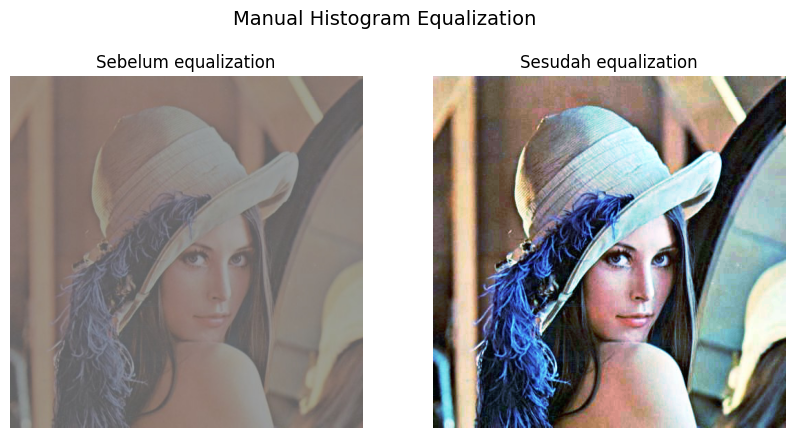

In [ ]:
img_lc = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020139/lena_lc.jpg')
img_lc_rgb = cv.cvtColor(img_lc, cv.COLOR_BGR2RGB)

def manual_histogram_equalization(channel):
    total_pixel = channel.size

    frekuensi = np.zeros(256)
    for value in channel.flatten():
      frekuensi[value] += 1

    cdf=np.zeros(256)
    cumulative_sum = 0
    for i in range(256):
      cumulative_sum += frekuensi[i]
      cdf[i] = cumulative_sum

    cdf_per_pixel = cdf/total_pixel
    K = 255
    hasil_equalization = np.round(cdf_per_pixel * K).astype(np.uint8)
    hasil_citra = hasil_equalization[channel]

    return hasil_citra

r, g, b = cv.split(img_lc_rgb)

r_eq_manual_lc = manual_histogram_equalization(r)
g_eq_manual_lc = manual_histogram_equalization(g)
b_eq_manual_lc = manual_histogram_equalization(b)

img_manual_eq = cv.merge((r_eq_manual_lc, g_eq_manual_lc, b_eq_manual_lc))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Manual Histogram Equalization', fontsize=14)

axs[0].imshow(img_lc_rgb)
axs[0].set_title('Sebelum equalization')
axs[0].axis('off')

axs[1].imshow(img_manual_eq)
axs[1].set_title('Sesudah equalization')
axs[1].axis('off')

plt.show()

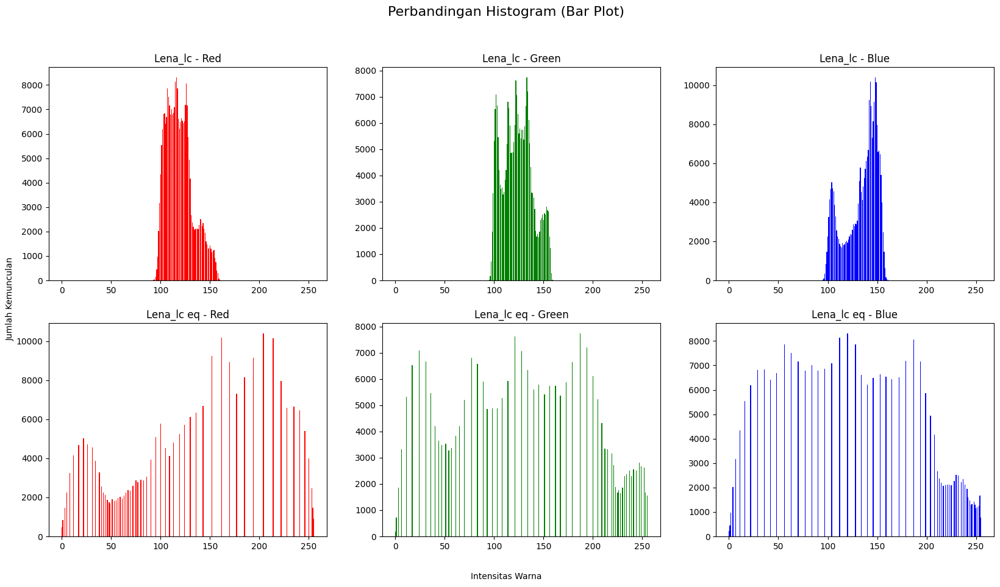

In [ ]:
height_lc, width_lc, depth_lc=np.shape(img_lc)
names=np.arange(256)

red_lc=[0]*256
green_lc=[0]*256
blue_lc=[0]*256

for y in range(0,height_lc):
  for x in range(0,width_lc):
    red_lc[img_lc[y][x][0]]+=1
    green_lc[img_lc[y][x][1]]+=1
    blue_lc[img_lc[y][x][2]]+=1

height_eq, width_eq, depth_eq=np.shape(img_manual_eq)
names=np.arange(256)

red_eq=[0]*256
green_eq=[0]*256
blue_eq=[0]*256

for y in range(0,height_eq):
  for x in range(0,width_eq):
    red_eq[img_manual_eq[y][x][0]]+=1
    green_eq[img_manual_eq[y][x][1]]+=1
    blue_eq[img_manual_eq[y][x][2]]+=1

fig, axs = plt.subplots(2, 3, figsize=[20, 10])
fig.suptitle('Perbandingan Histogram (Bar Plot)', fontsize=16)
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0, 0].bar(names, red_lc, color='red')
axs[0, 0].set_title('Lena_lc - Red')
axs[0, 1].bar(names, green_lc, color='green')
axs[0, 1].set_title('Lena_lc - Green')
axs[0, 2].bar(names, blue_lc, color='blue')
axs[0, 2].set_title('Lena_lc - Blue')

axs[1, 0].bar(names, red_eq, color='red')
axs[1, 0].set_title('Lena_lc eq - Red')
axs[1, 1].bar(names, green_eq, color='green')
axs[1, 1].set_title('Lena_lc eq - Green')
axs[1, 2].bar(names, blue_eq, color='blue')
axs[1, 2].set_title('Lena_lc eq - Blue')

plt.show()

## ulangi pada citra KTM1a.jpg



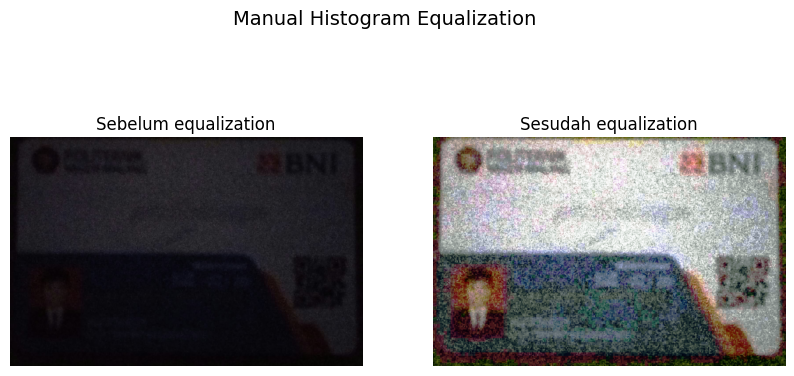

In [ ]:
img_ktm1a=cv.imread('/content/drive/MyDrive/PCVK/Images/244107020139/KTM1a.jpeg')
img_ktm1a=cv.cvtColor(img_ktm1a,cv.COLOR_BGR2RGB)

r_ktm1a, g_ktm1a, b_ktm1a = cv.split(img_ktm1a)

r_eq_ktm1a_manual = manual_histogram_equalization(r_ktm1a)
g_eq_ktm1a_manual = manual_histogram_equalization(g_ktm1a)
b_eq_ktm1a_manual = manual_histogram_equalization(b_ktm1a)

img_eq_ktm1a_manual = cv.merge((r_eq_ktm1a_manual, g_eq_ktm1a_manual, b_eq_ktm1a_manual))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Manual Histogram Equalization', fontsize=14)

axs[0].imshow(img_ktm1a)
axs[0].set_title('Sebelum equalization')
axs[0].axis('off')

axs[1].imshow(img_eq_ktm1a_manual)
axs[1].set_title('Sesudah equalization')
axs[1].axis('off')

plt.show()

Text(0.5, 1.0, 'ktm1a eq - Blue')

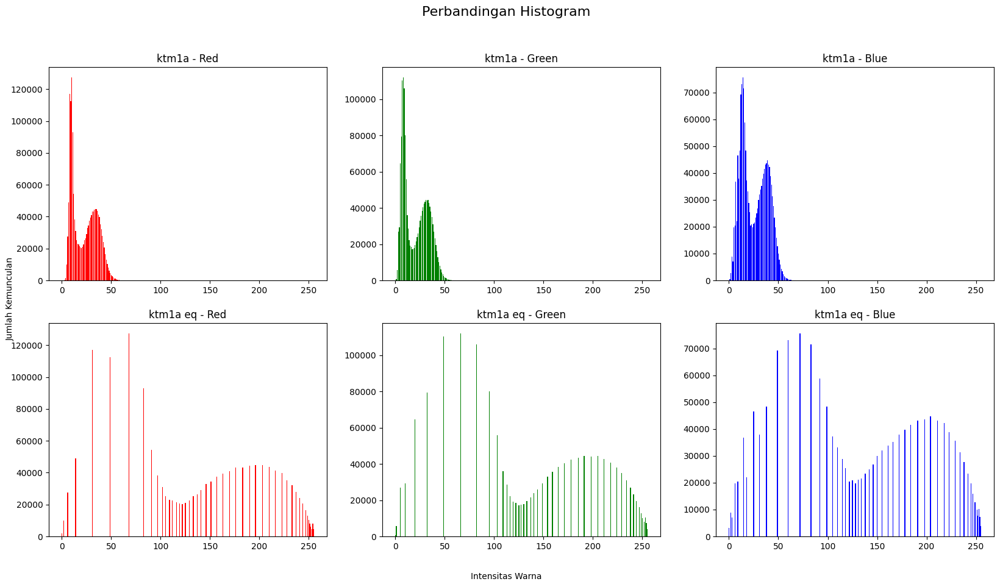

In [ ]:
height_ktm1a, width_ktm1a, depth_ktm1a=np.shape(img_ktm1a)
names=np.arange(256)

red_ktm1a=[0]*256
green_ktm1a=[0]*256
blue_ktm1a=[0]*256

for y in range(0,height_ktm1a):
  for x in range(0,width_ktm1a):
    red_ktm1a[img_ktm1a[y][x][0]]+=1
    green_ktm1a[img_ktm1a[y][x][1]]+=1
    blue_ktm1a[img_ktm1a[y][x][2]]+=1

height_eq_ktm1a, width_eq_ktm1a, depth_eq_ktm1a=np.shape(img_eq_ktm1a_manual)
names=np.arange(256)

red_eq_ktm1a=[0]*256
green_eq_ktm1a=[0]*256
blue_eq_ktm1a=[0]*256

for y in range(0,height_eq_ktm1a):
  for x in range(0,width_eq_ktm1a):
    red_eq_ktm1a[img_eq_ktm1a_manual[y][x][0]]+=1
    green_eq_ktm1a[img_eq_ktm1a_manual[y][x][1]]+=1
    blue_eq_ktm1a[img_eq_ktm1a_manual[y][x][2]]+=1

fig, axs = plt.subplots(2, 3, figsize=[20, 10])
fig.suptitle('Perbandingan Histogram', fontsize=16)
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0, 0].bar(names, red_ktm1a, color='red')
axs[0, 0].set_title('ktm1a - Red')
axs[0, 1].bar(names, green_ktm1a, color='green')
axs[0, 1].set_title('ktm1a - Green')
axs[0, 2].bar(names, blue_ktm1a, color='blue')
axs[0, 2].set_title('ktm1a - Blue')

axs[1, 0].bar(names, red_eq_ktm1a, color='red')
axs[1, 0].set_title('ktm1a eq - Red')
axs[1, 1].bar(names, green_eq_ktm1a, color='green')
axs[1, 1].set_title('ktm1a eq - Green')
axs[1, 2].bar(names, blue_eq_ktm1a, color='blue')
axs[1, 2].set_title('ktm1a eq - Blue')

## buatlah histogram citra yang sama menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist”. Bandingkan hasil equalizeHist dengan hasil implementasi manual Anda dengan menghitung selisih maksimum antara keduanya

In [ ]:
b_lc, g_lc, r_lc = cv.split(img_lc)

b_eq_lc = cv.equalizeHist(b_lc)
g_eq_lc = cv.equalizeHist(g_lc)
r_eq_lc = cv.equalizeHist(r_lc)

b_ktm1a, g_ktm1a, r_ktm1a = cv.split(cv.cvtColor(img_ktm1a, cv.COLOR_RGB2BGR))

b_eq_ktm1a = cv.equalizeHist(b_ktm1a)
g_eq_ktm1a = cv.equalizeHist(g_ktm1a)
r_eq_ktm1a = cv.equalizeHist(r_ktm1a)

diff_b_lc = np.max(np.abs(b_eq_lc.astype(int) - b_eq_manual_lc.astype(int)))
diff_g_lc = np.max(np.abs(g_eq_lc.astype(int) - g_eq_manual_lc.astype(int)))
diff_r_lc = np.max(np.abs(r_eq_lc.astype(int) - r_eq_manual_lc.astype(int)))

diff_b_ktm1a = np.max(np.abs(b_eq_ktm1a.astype(int) - b_eq_ktm1a_manual.astype(int)))
diff_g_ktm1a = np.max(np.abs(g_eq_ktm1a.astype(int) - g_eq_ktm1a_manual.astype(int)))
diff_r_ktm1a = np.max(np.abs(r_eq_ktm1a.astype(int) - r_eq_ktm1a_manual.astype(int)))

print("selisih maksimum lena_lc")
print(f"Blue Channel : {diff_b_lc}")
print(f"Green Channel : {diff_g_lc}")
print(f"Red Channel : {diff_r_lc}")

print("Selisih maksimum KTM1a")
print(f"Blue Channel : {diff_b_ktm1a}")
print(f"Green Channel : {diff_g_ktm1a}")
print(f"Red Channel : {diff_r_ktm1a}")

selisih maksimum lena_lc
Blue Channel : 0
Green Channel : 0
Red Channel : 0
Selisih maksimum KTM1a
Blue Channel : 0
Green Channel : 1
Red Channel : 0


## Ekualisasi juga dapat diterapkan pada citra berwarna. Cara yang biasanya pertama kali terpikirkan adalah mengekualisasi kanal biru, hijau, dan merah satu per satu.

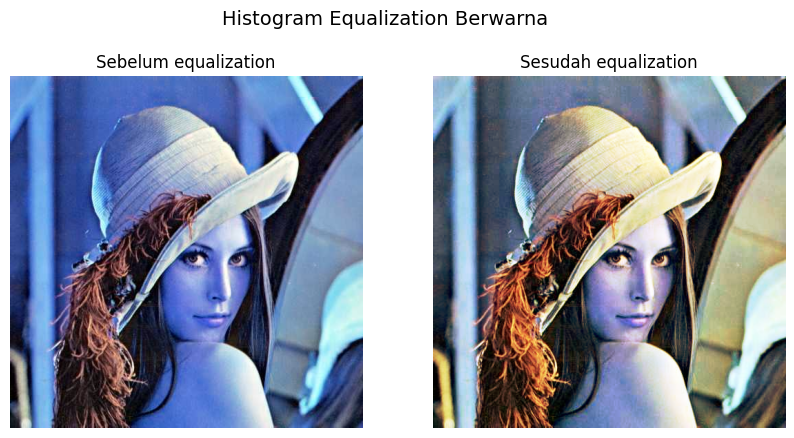

In [ ]:
berkas='/content/drive/MyDrive/PCVK/Images/244107020139/lena.jpg'
bgr=cv.imread(berkas)

kanal = list(cv.split(bgr))
for i in range(3):
  kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Histogram Equalization Berwarna', fontsize=14)

axs[0].imshow(bgr)
axs[0].set_title('Sebelum equalization')
axs[0].axis('off')

axs[1].imshow(he_rgb)
axs[1].set_title('Sesudah equalization')
axs[1].axis('off')

plt.show()

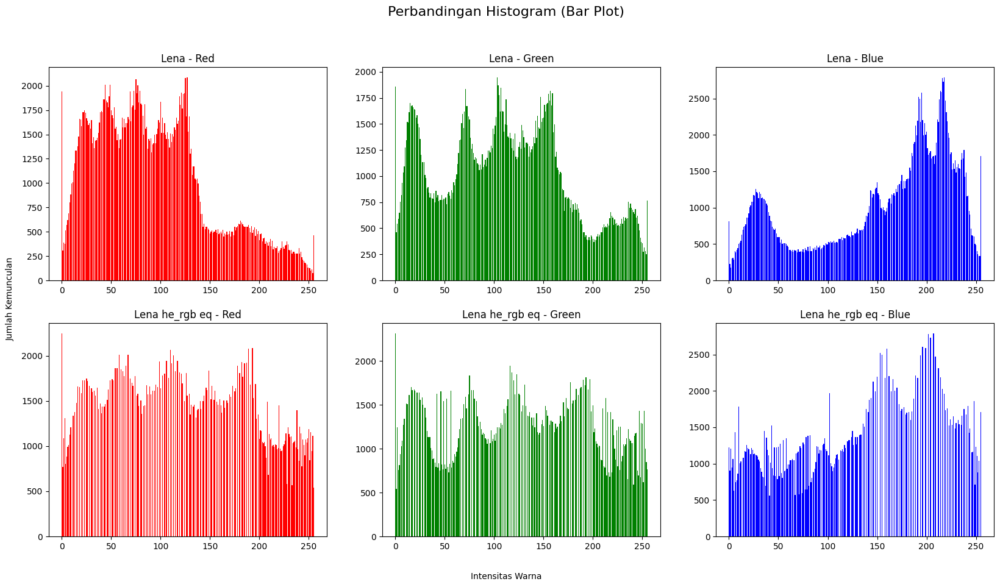

In [ ]:
height_bgr, width_bgr, depth_bgr=np.shape(bgr)
names=np.arange(256)

red_bgr=[0]*256
green_bgr=[0]*256
blue_bgr=[0]*256

for y in range(0,height_bgr):
  for x in range(0,width_bgr):
    red_bgr[bgr[y][x][0]]+=1
    green_bgr[bgr[y][x][1]]+=1
    blue_bgr[bgr[y][x][2]]+=1

height_he_rgb, width_ge_rgb, depth_he_rgb=np.shape(he_rgb)
names=np.arange(256)

red_he_rgb=[0]*256
green_he_rgb=[0]*256
blue_he_rgb=[0]*256

for y in range(0,height_he_rgb):
  for x in range(0,width_ge_rgb):
    red_he_rgb[he_rgb[y][x][0]]+=1
    green_he_rgb[he_rgb[y][x][1]]+=1
    blue_he_rgb[he_rgb[y][x][2]]+=1

fig, axs = plt.subplots(2, 3, figsize=[20, 10])
fig.suptitle('Perbandingan Histogram (Bar Plot)', fontsize=16)
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0, 0].bar(names, red_bgr, color='red')
axs[0, 0].set_title('Lena - Red')
axs[0, 1].bar(names, green_bgr, color='green')
axs[0, 1].set_title('Lena - Green')
axs[0, 2].bar(names, blue_bgr, color='blue')
axs[0, 2].set_title('Lena - Blue')

axs[1, 0].bar(names, red_he_rgb, color='red')
axs[1, 0].set_title('Lena he_rgb eq - Red')
axs[1, 1].bar(names, green_he_rgb, color='green')
axs[1, 1].set_title('Lena he_rgb eq - Green')
axs[1, 2].bar(names, blue_he_rgb, color='blue')
axs[1, 2].set_title('Lena he_rgb eq - Blue')

plt.show()

##  ulangi pada KTM1d.jpg

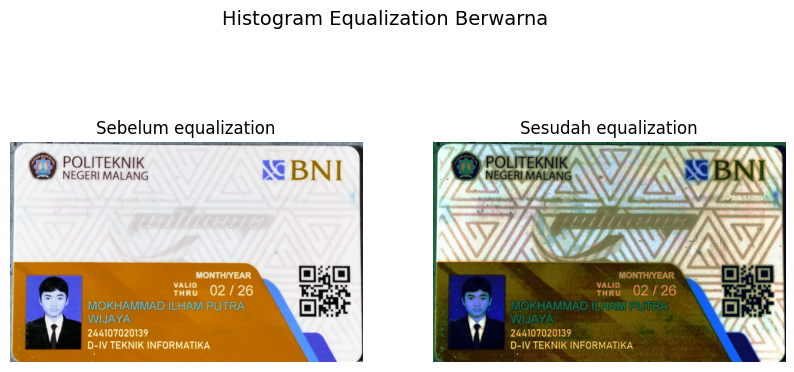

In [ ]:
berkas_ktm1d='/content/drive/MyDrive/PCVK/Images/244107020139/KTM1d.jpeg'
bgr_ktm1d=cv.imread(berkas_ktm1d)

kanal = list(cv.split(bgr_ktm1d))
for i in range(3):
  kanal[i] = cv.equalizeHist(kanal[i])
he_rgb_ktm1d = cv.merge(kanal)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Histogram Equalization Berwarna', fontsize=14)

axs[0].imshow(bgr_ktm1d)
axs[0].set_title('Sebelum equalization')
axs[0].axis('off')

axs[1].imshow(he_rgb_ktm1d)
axs[1].set_title('Sesudah equalization')
axs[1].axis('off')

plt.show()

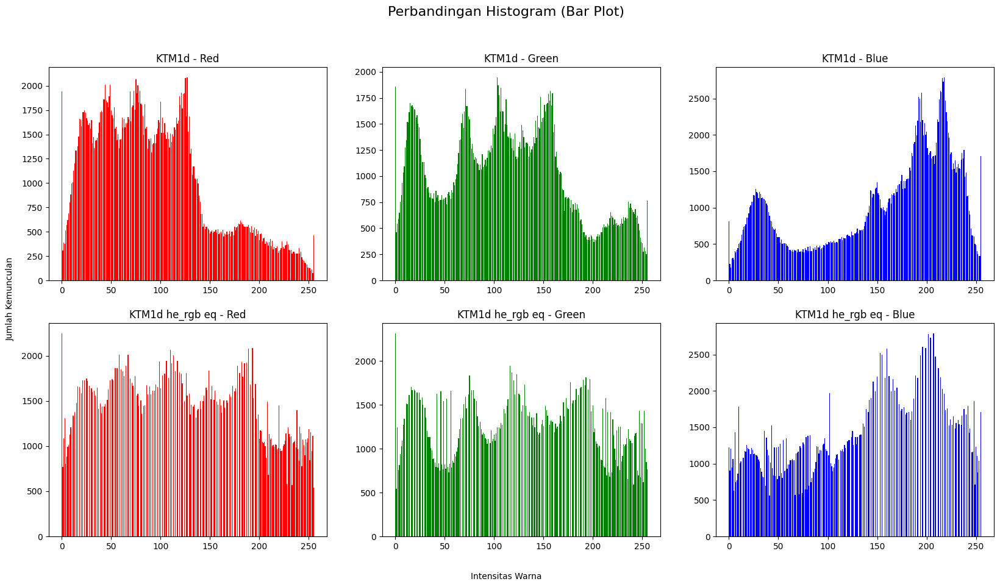

In [ ]:
height, width, depth=np.shape(bgr_ktm1d)
names=np.arange(256)

red=[0]*256
green=[0]*256
blue=[0]*256

for y in range(0,height):
  for x in range(0,width):
    red[bgr_ktm1d[y][x][0]]+=1
    green[bgr_ktm1d[y][x][1]]+=1
    blue[bgr_ktm1d[y][x][2]]+=1

height_ktm1d, width_ktm1d, depth_ktm1d=np.shape(he_rgb_ktm1d)
names=np.arange(256)

red_ktm1d=[0]*256
green_ktm1d=[0]*256
blue_ktm1d=[0]*256

for y in range(0,height_ktm1d):
  for x in range(0,width_ktm1d):
    red_ktm1d[he_rgb_ktm1d[y][x][0]]+=1
    green_ktm1d[he_rgb_ktm1d[y][x][1]]+=1
    blue[he_rgb_ktm1d[y][x][2]]+=1

fig, axs = plt.subplots(2, 3, figsize=[20, 10])
fig.suptitle('Perbandingan Histogram (Bar Plot)', fontsize=16)
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0, 0].bar(names, red_bgr, color='red')
axs[0, 0].set_title('KTM1d - Red')
axs[0, 1].bar(names, green_bgr, color='green')
axs[0, 1].set_title('KTM1d - Green')
axs[0, 2].bar(names, blue_bgr, color='blue')
axs[0, 2].set_title('KTM1d - Blue')

axs[1, 0].bar(names, red_he_rgb, color='red')
axs[1, 0].set_title('KTM1d he_rgb eq - Red')
axs[1, 1].bar(names, green_he_rgb, color='green')
axs[1, 1].set_title('KTM1d he_rgb eq - Green')
axs[1, 2].bar(names, blue_he_rgb, color='blue')
axs[1, 2].set_title('KTM1d he_rgb eq - Blue')

plt.show()

## Cara kedua memisahkan kecerahan dari informasi warna. Citra diubah ke ruang warna YCrCb, hanya kanal Y yang diekualisasi, lalu dikembalikan ke BGR. Kanal Cr dan Cb yang menyimpan informasi warna tidak disentuh sama sekali. Kanal V pada HSV dan kanal L pada LAB berperan serupa, sehingga ketiganya dicoba sekaligus.

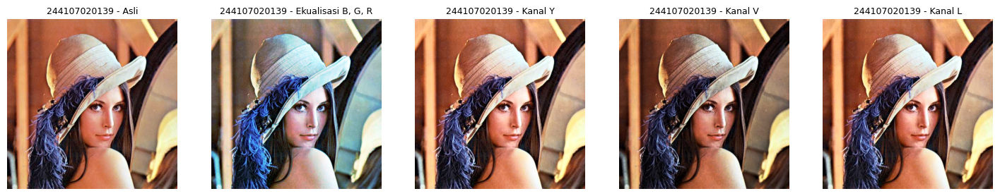

In [ ]:
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]
plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
  plt.subplot(1, 5, i)
  plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
  plt.title(NIM + ' - ' + t, fontsize=9)
  plt.axis('off')
plt.show()

In [ ]:
def geser_hue(asli, hasil):
  h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
  h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
  d = np.abs(h1 - h2)
  d = np.minimum(d, 180 - d)
  return d.mean()
print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
  print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2, cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            122.2
Ekualisasi B, G, R                53.03            127.4
Kanal Y                            0.40            127.9
Kanal V                            0.87            100.6
Kanal L                            1.65            122.7


## gunakan KTM1d.jpg

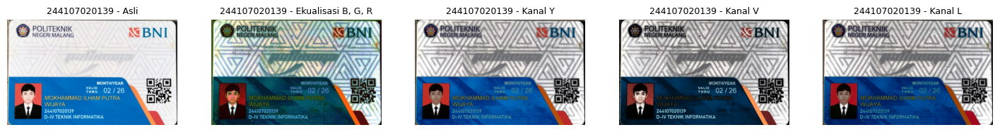

In [ ]:
ycrcb = cv.cvtColor(bgr_ktm1d, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv = cv.cvtColor(bgr_ktm1d, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr_ktm1d, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr_ktm1d, he_rgb_ktm1d, he_y, he_v, he_l]
plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
 plt.subplot(1, 5, i)
 plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
 plt.title(NIM + ' - ' + t, fontsize=9)
 plt.axis('off')
plt.show()

In [ ]:
print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
  print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr_ktm1d, c) * 2, cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            173.4
Ekualisasi B, G, R                53.74            123.0
Kanal Y                            1.85            132.6
Kanal V                            2.74            116.8
Kanal L                            8.28            123.5


### Jawab pertanyaan berikut berdasarkan angka pada tabel Anda, bukan hanya dari pengamatan mata:
1. Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada citra Anda?<br>
Jawab: Dengan menerapkan metode yang menyetarakan saluran B, G, dan R secara terpisah, sehingga mengubah intensitas setiap saluran secara independen, hubungan proporsional antara warna merah, hijau, dan biru yang menentukan rona warna menjadi terganggu, yang pada akhirnya mengakibatkan distorsi warna yang signifikan.
2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis nol? Kaitkan jawaban Anda dengan pembulatan dan pemotongan nilai ketika citra dikembalikan ke ruang warna BGR.<br>
Jawab: Pergeseran tetap muncul saat citra dikonversi kembali ke BGR akibat 2 hal:
- Pembulatan: Perhitungan konversi ke format BGR dapat menghasilkan nilai desimal yang harus dibulatkan ke bilangan bulat 8-bit, menyebabkan sedikit pergeseran rasio warna.
- Pemotongan: Peningkatan kontras dapat menghasilkan nilai yang berada di luar rentang yang valid; nilai-nilai ini secara otomatis dipotong menjadi 0 atau 255, mengubah rasio warna piksel asli.
3. Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM Anda? Sebutkan alasannya dan tunjukkan bagian citra yang menjadi dasar penilaian.<br>
Jawab: Kanal Y, karena berhasil meningkatkan kontras pola latar belakang peta tanpa membuat bagian bawahnya menjadi hitam pekat, tidak seperti Kanal V. kanal Y berfungsi sebagai dasar untuk menilai bagian teks yang berisi data identifikasi, karena latar belakang biru tetap seimbang, memastikan kontras teks yang baik dan keterbacaan yang optimal.
4. Ulangi salah satu cara pada kanal terang dengan mengganti cv.equalizeHist menjadi CLAHE yang memakai clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan pergeseran Hue dan rerata kecerahannya dengan hasil ekualisasi biasa.

In [ ]:
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))

ycrcb = cv.cvtColor(bgr_ktm1d, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
y_clahe = clahe.apply(y)
he_y_clahe = cv.cvtColor(cv.merge([y_clahe, cr, cb]), cv.COLOR_YCrCb2BGR)

clahe_geser = geser_hue(bgr_ktm1d, he_y_clahe) * 2
clahe_terang = cv.cvtColor(he_y_clahe, cv.COLOR_BGR2GRAY).mean()

print(f'CLAHE kanal Y')
print(f'geser hue: {clahe_geser:.2f}')
print(f'rerata terang: {clahe_terang:.1f}')

CLAHE kanal Y
geser hue: 0.32
rerata terang: 161.4


- Pergeseran hue: Ukuran file sangat kecil, jauh lebih kecil daripada dengan pemerataan standar. Pengurangan kontras mencegah puncak intensitas yang ekstrem, meminimalkan clipping selama konversi kembali ke BGR, dan menjamin akurasi warna.
- Rerata Kecerahan: Pencahayaan yang seimbang dan proporsional. Berbeda dengan ekualisasi global yang sering kali menyebabkan pencahayaan berlebih, CLAHE bekerja secara adaptif berdasarkan segmen-segmen individual. Hal ini memastikan bahwa area terang tidak mengalami pencahayaan berlebih dan detail teks di area gelap tetap terbaca dengan jelas.

## PERTANYAAN PRAKTIKUM E2

1. Ekualisasi global pada citra KTM Anda <br>
    a. Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi grayscale.<br>
    b. Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout. <br>
    c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR layak dipakai untuk menilai keterbacaan sebuah citra.

In [ ]:
grayscale_ktm1a = cv.cvtColor(img_ktm1a, cv.COLOR_BGR2GRAY)
grayscale_ktm1a_manual_eq = manual_histogram_equalization(grayscale_ktm1a)

grayscale_ktm1a_eq = cv.equalizeHist(grayscale_ktm1a)

diff_grayscale_ktm1a = np.max(np.abs(grayscale_ktm1a_eq.astype(int) - grayscale_ktm1a_manual_eq.astype(int)))

print(f"selisih maksimum grayscale_ktm1a = {diff_grayscale_ktm1a}")

selisih maksimum grayscale_ktm1a = 0


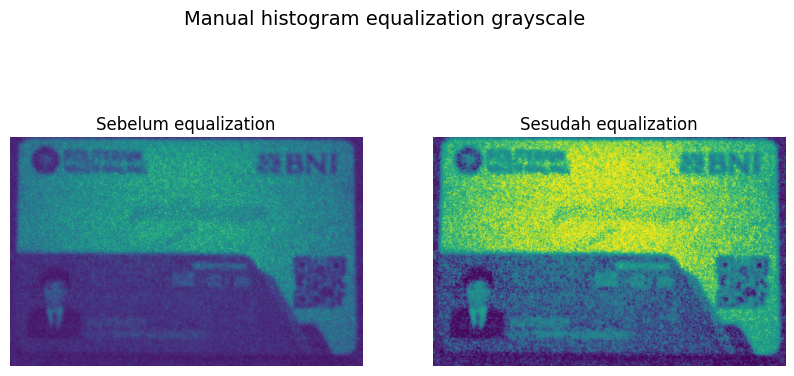

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Manual histogram equalization grayscale', fontsize=14)

axs[0].imshow(grayscale_ktm1a)
axs[0].set_title('Sebelum equalization')
axs[0].axis('off')

axs[1].imshow(grayscale_ktm1a_manual_eq)
axs[1].set_title('Sesudah equalization')
axs[1].axis('off')

plt.show()

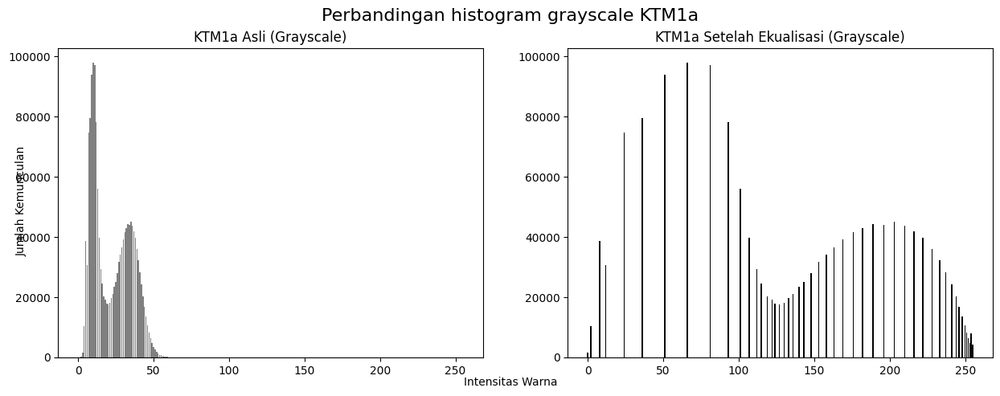

In [ ]:
hist_asli = [0]*256
hist_eq = [0]*256

for y in range(grayscale_ktm1a.shape[0]):
  for x in range(grayscale_ktm1a.shape[1]):
    hist_asli[grayscale_ktm1a[y][x]] += 1

for y in range(grayscale_ktm1a_manual_eq.shape[0]):
  for x in range(grayscale_ktm1a_manual_eq.shape[1]):
    hist_eq[grayscale_ktm1a_manual_eq[y][x]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Perbandingan histogram grayscale KTM1a', fontsize=16)
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, hist_asli, color='gray')
axs[0].set_title('KTM1a Asli (Grayscale)')

axs[1].bar(names, hist_eq, color='black')
axs[1].set_title('KTM1a Setelah Ekualisasi (Grayscale)')

plt.show()

In [ ]:
import math

def hitung_psnr(citra_asli, citra_hasil):
  mse = np.mean((citra_asli.astype(np.float64) - citra_hasil.astype(np.float64)) ** 2)
  if mse == 0:
    return float('inf')
  max_pixel = 255.0
  psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
  return psnr

psnr_value = hitung_psnr(grayscale_ktm1a, grayscale_ktm1a_manual_eq)
print(f"Nilai PSNR antara citra asli dan citra hasil ekualisasi: {psnr_value:.2f} dB")

Nilai PSNR antara citra asli dan citra hasil ekualisasi: 6.24 dB


2. Ekualisasi lokal dengan CLAHE pada citra KTM Anda<br>
    a. Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?<br>
    b. Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang noise-nya mulai menonjol ketika clipLimit dinaikkan

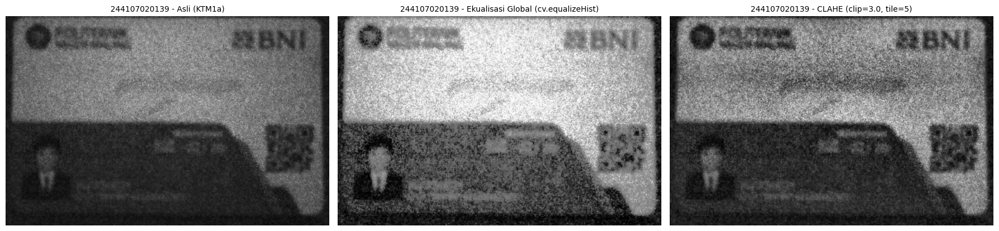

In [ ]:
clip_base = PARAM['clip']
tile_base = (PARAM['tile'], PARAM['tile'])

clahe_default = cv.createCLAHE(clipLimit=clip_base, tileGridSize=tile_base)
grayscale_ktm1a_clahe_default = clahe_default.apply(grayscale_ktm1a)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(grayscale_ktm1a, cmap='gray')
axs[0].set_title(f"{NIM} - Asli (KTM1a)", fontsize=10)
axs[0].axis('off')

axs[1].imshow(grayscale_ktm1a_eq, cmap='gray')
axs[1].set_title(f"{NIM} - Ekualisasi Global (cv.equalizeHist)", fontsize=10)
axs[1].axis('off')

axs[2].imshow(grayscale_ktm1a_clahe_default, cmap='gray')
axs[2].set_title(f"{NIM} - CLAHE (clip={clip_base}, tile={PARAM['tile']})", fontsize=10)
axs[2].axis('off')
plt.tight_layout()
plt.show()

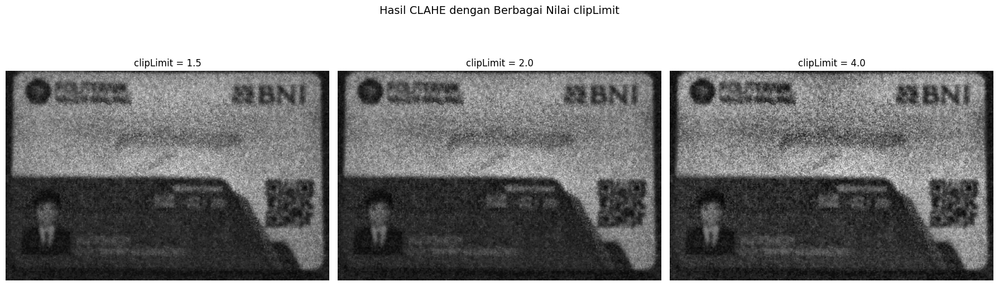

In [ ]:
clip_lain = [1.5, 2.0, 4.0]
hasil_variasi = []
for c in clip_lain:
  clahe_variasi = cv.createCLAHE(clipLimit=c, tileGridSize=tile_base)
  hasil_variasi.append(clahe_variasi.apply(grayscale_ktm1a))

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Hasil CLAHE dengan Berbagai Nilai clipLimit', fontsize=14)

for i, (img_res, clip) in enumerate(zip(hasil_variasi, clip_lain)):
  axs[i].imshow(img_res, cmap='gray')
  axs[i].set_title(f'clipLimit = {clip}')
  axs[i].axis('off')

plt.tight_layout()
plt.show()

# 1. Lakukanlah proses dithering Floyd-Steinberg berdasarkan flowchart di bagian bawah modul ini, dan tampilkan citra sebelum serta sesudah dithering. Tahap 1 gunakan lena.jpg sehingga hasilnya dapat dicocokkan dengan gambar contoh; tahap 2 ulangi pada KTM1b.jpg dengan jumlah level PARAM['L'].

In [ ]:
def floyd_steinberg(gray, L=2):
  img = gray.astype(np.float32).copy()
  step = 255.0 / (L - 1)
  H, W = img.shape

  for y in range(H):
    for x in range(W):
      lama = img[y, x]
      baru = np.round(lama / step) * step
      img[y, x] = baru
      error = lama - baru

      if x + 1 < W:
        img[y, x + 1] += error * (7 / 16)
      if x > 0 and y + 1 < H:
        img[y + 1, x - 1] += error * (3 / 16)
      if y + 1 < H:
        img[y + 1, x] += error * (5 / 16)
      if x + 1 < W and y + 1 < H:
        img[y + 1, x + 1] += error * (1 / 16)

  return np.clip(img, 0, 255).astype(np.uint8)

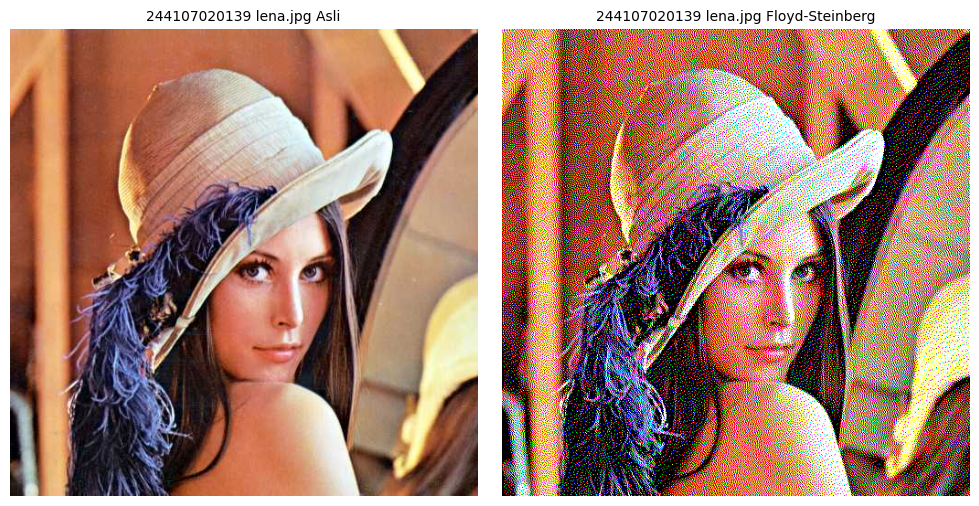

In [ ]:
b, g, r = cv.split(bgr)
b_floyd = floyd_steinberg(b)
g_floyd = floyd_steinberg(g)
r_floyd = floyd_steinberg(r)

lena_dither = cv.merge([b_floyd, g_floyd, r_floyd])

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' lena.jpg Asli', fontsize=10)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(lena_dither, cv.COLOR_BGR2RGB))
plt.title(NIM + ' lena.jpg Floyd-Steinberg', fontsize=10)
plt.axis('off')
plt.tight_layout()
plt.show()

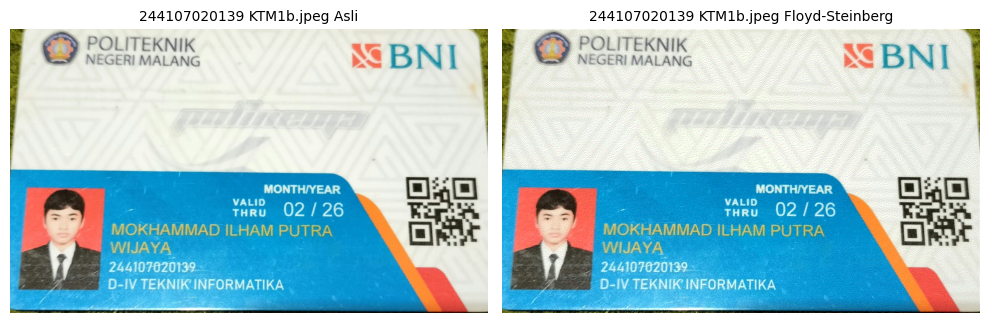

In [ ]:
img_ktm1b = '/content/drive/MyDrive/PCVK/Images/244107020139/KTM1b.jpeg'
img_ktm1b = cv.imread(img_ktm1b)

b_ktm1b, g_ktm1b, r_ktm1b = cv.split(img_ktm1b)
b_ktm1b_floyd = floyd_steinberg(b_ktm1b)
g_ktm1b_floyd = floyd_steinberg(g_ktm1b)
r_ktm1b_floyd = floyd_steinberg(r_ktm1b)

ktm1b_dither = cv.merge([b_ktm1b_floyd, g_ktm1b_floyd, r_ktm1b_floyd])

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img_ktm1b, cv.COLOR_BGR2RGB))
plt.title(NIM + ' KTM1b.jpeg Asli', fontsize=10)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(ktm1b_dither, cv.COLOR_BGR2RGB))
plt.title(NIM + ' KTM1b.jpeg Floyd-Steinberg', fontsize=10)
plt.axis('off')
plt.tight_layout()
plt.show()

# 2. Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaran intensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil ekualisasi tersebut. Kerjakan lebih dulu pada lena_lc.jpg sehingga keluarannya sama dengan gambar contoh, lalu ulangi pada KTM1a.jpg. Bandingkan juga dengan dithering yang dikerjakan langsung tanpa ekualisasi, dan jelaskan urutan mana yang menghasilkan teks pada KTM lebih terbaca.

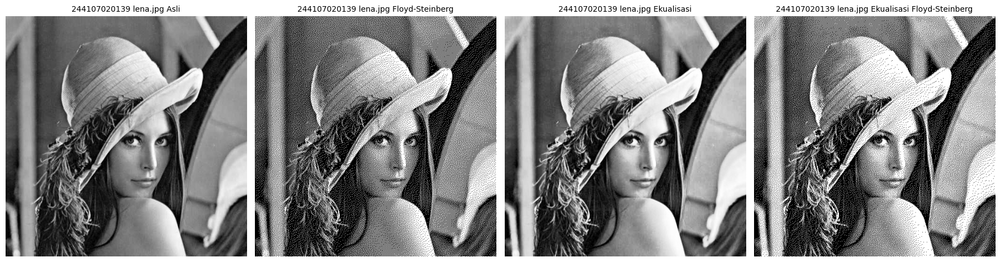

In [ ]:
grayscale_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
grayscale_img_dither = floyd_steinberg(grayscale_img)
grayscale_img_eq = cv.equalizeHist(grayscale_img)
grayscale_img_eq_dither = floyd_steinberg(grayscale_img_eq)

plt.figure(figsize=(18, 5))
plt.subplot(1, 4, 1)
plt.imshow(grayscale_img, cmap='gray')
plt.title(NIM + ' lena.jpg Asli', fontsize=10)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(grayscale_img_dither, cmap='gray')
plt.title(NIM + ' lena.jpg Floyd-Steinberg', fontsize=10)
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(grayscale_img_eq, cmap='gray')
plt.title(NIM + ' lena.jpg Ekualisasi', fontsize=10)
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(grayscale_img_eq_dither, cmap='gray')
plt.title(NIM + ' lena.jpg Ekualisasi Floyd-Steinberg', fontsize=10)
plt.axis('off')
plt.tight_layout()
plt.show()

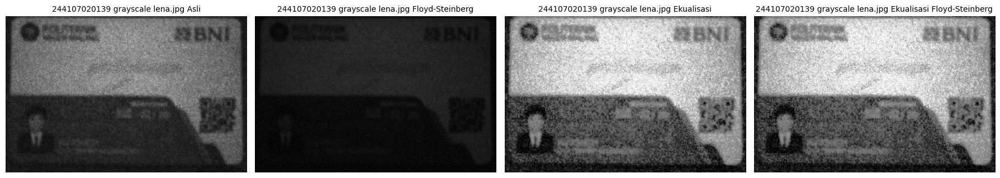

In [ ]:
grayscale_ktm1a_dither = floyd_steinberg(grayscale_ktm1a)
grayscale_ktm1a_eq_dither = floyd_steinberg(grayscale_ktm1a_eq)

plt.figure(figsize=(18, 5))
plt.subplot(1, 4, 1)
plt.imshow(grayscale_ktm1a, cmap='gray')
plt.title(NIM + ' grayscale lena.jpg Asli', fontsize=10)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(grayscale_ktm1a_dither, cmap='gray')
plt.title(NIM + ' grayscale lena.jpg Floyd-Steinberg', fontsize=10)
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(grayscale_ktm1a_eq, cmap='gray')
plt.title(NIM + ' grayscale lena.jpg Ekualisasi', fontsize=10)
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(grayscale_ktm1a_eq_dither, cmap='gray')
plt.title(NIM + ' grayscale lena.jpg Ekualisasi Floyd-Steinberg', fontsize=10)
plt.axis('off')
plt.tight_layout()
plt.show()

teks pada KTM tersebut menurut saya tidak bisa terbaca, tetapi urutan yang menghasilkan citra baik yaitu ekualisasi dahulu lalu dithering.
- jika melakukan dithering langsung, citra menjadi hitam dan tidak terlihat teks dan pasfoto ktm.
- jika melakukan ekualisasi lalu dithering, kualitas citrainya cerah dan pasfoto ktm terlihat, walaupun teks NIM, nama, serta detail kartu kurang terlihat jelas.